# 09 - Team Classification

## Obiettivo

Associare ciascun player track ad una delle due squadre utilizzando
principalmente le informazioni visive della divisa.

La classificazione viene effettuata a livello di track e non di singolo frame,
in modo da sfruttare più osservazioni dello stesso giocatore e ridurre
l'effetto di:

- illuminazione;
- motion blur;
- occlusioni;
- pose differenti.

Pipeline:

player tracks
→ player crop
→ torso crop
→ color features
→ aggregation per track
→ clustering / classification
→ team label

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/basketball-thesis"
)

SEQUENCE_NAME = "v_00HRwkvvjtQ_c001"

FRAMES_DIR = (
    DRIVE_ROOT
    / "datasets"
    / "sportsmot"
    / "val"
    / SEQUENCE_NAME
    / "img1"
)

TRACKS_CSV = (
    DRIVE_ROOT
    / "experiments"
    / "bytetrack_baseline"
    / f"{SEQUENCE_NAME}_tracks.csv"
)

OUTPUT_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "team_classification"
    / SEQUENCE_NAME
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Frames:", FRAMES_DIR.exists())
print("Tracks:", TRACKS_CSV.exists())
print("Output:", OUTPUT_DIR)

Frames: True
Tracks: True
Output: /content/drive/MyDrive/basketball-thesis/experiments/team_classification/v_00HRwkvvjtQ_c001


Caricamento Tracking

In [4]:
tracks_df = pd.read_csv(
    TRACKS_CSV
)

print("Observations:", len(tracks_df))
print(
    "Unique track IDs:",
    tracks_df["track_id"].nunique()
)

print(
    tracks_df.columns.tolist()
)

display(
    tracks_df.head()
)

Observations: 10911
Unique track IDs: 27
['frame', 'time', 'track_id', 'confidence', 'x1', 'y1', 'x2', 'y2']


,frame,time,track_id,confidence,x1,y1,x2,y2
0,2,0.04,0,0.946324,434.150208,268.251038,560.730225,436.969086
1,2,0.04,1,0.918907,973.851013,390.865112,1050.417969,604.696655
2,2,0.04,2,0.847887,636.885437,416.111542,768.735291,625.620422
3,2,0.04,3,0.852696,990.499023,290.476715,1053.694336,497.539978
4,2,0.04,4,0.760175,652.945068,272.642029,758.719971,433.214264


In [5]:
print(
    tracks_df.columns.tolist()
)

['frame', 'time', 'track_id', 'confidence', 'x1', 'y1', 'x2', 'y2']


Distribuzione Colonne Track

In [6]:
track_counts = (
    tracks_df["track_id"]
    .value_counts()
    .sort_values(
        ascending=False
    )
)

display(
    track_counts.to_frame(
        "observations"
    )
)

print(
    "Median track length:",
    track_counts.median()
)

,observations
track_id,
0,1151
4,1144
11,1035
14,971
6,896
15,886
8,807
1,780
13,509


Median track length: 274.0


## Estrazione dei player crop

Per ogni bounding box del tracker viene estratta l'immagine del giocatore.

Per la classificazione della squadra verrà utilizzata principalmente la
regione superiore del corpo, poiché contiene la parte più informativa
della divisa e riduce l'influenza di parquet, scarpe e sfondo.

Funzione player Crop

In [7]:
def extract_player_crop(
    frame,
    x1,
    y1,
    x2,
    y2,
):

    h, w = frame.shape[:2]

    x1 = max(
        0,
        int(round(x1))
    )

    y1 = max(
        0,
        int(round(y1))
    )

    x2 = min(
        w,
        int(round(x2))
    )

    y2 = min(
        h,
        int(round(y2))
    )

    if x2 <= x1 or y2 <= y1:
        return None

    crop = frame[
        y1:y2,
        x1:x2
    ]

    return crop

Regione Torso

In [8]:
def extract_torso(player_crop):

    if player_crop is None:
        return None

    h, w = player_crop.shape[:2]

    if h < 20 or w < 10:
        return None

    y1 = int(0.18 * h)
    y2 = int(0.52 * h)

    x1 = int(0.25 * w)
    x2 = int(0.75 * w)

    torso = player_crop[
        y1:y2,
        x1:x2
    ]

    if torso.size == 0:
        return None

    return torso

Selezione Track Lungo

In [9]:
TEST_TRACK_ID = int(
    track_counts.index[0]
)

test_track = (
    tracks_df[
        tracks_df["track_id"]
        == TEST_TRACK_ID
    ]
    .sort_values("frame")
)

sample_row = (
    test_track
    .iloc[
        len(test_track) // 2
    ]
)

print(
    "Track ID:",
    TEST_TRACK_ID
)

display(
    sample_row.to_frame(
        "value"
    )
)

Track ID: 0


,value
frame,583.000000
time,23.280000
track_id,0.000000
confidence,0.926605
x1,786.381592
y1,293.822815
x2,878.950562
y2,454.069489


Visualizzazione player e torso

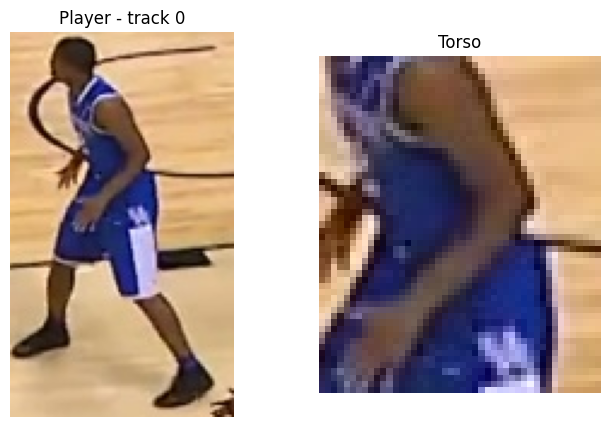

In [10]:
frame_number = int(
    sample_row["frame"]
)

frame_path = (
    FRAMES_DIR
    / f"{frame_number:06d}.jpg"
)

frame = cv2.imread(
    str(frame_path)
)

assert frame is not None

player_crop = extract_player_crop(
    frame,
    sample_row["x1"],
    sample_row["y1"],
    sample_row["x2"],
    sample_row["y2"],
)

torso_crop = extract_torso(
    player_crop
)

plt.figure(
    figsize=(8, 5)
)

plt.subplot(
    1,
    2,
    1
)

plt.imshow(
    cv2.cvtColor(
        player_crop,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    f"Player - track {TEST_TRACK_ID}"
)

plt.axis("off")

plt.subplot(
    1,
    2,
    2
)

plt.imshow(
    cv2.cvtColor(
        torso_crop,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Torso")

plt.axis("off")

plt.show()

Feature Colore

In [11]:
def color_features(torso):

    if torso is None or torso.size == 0:
        return None

    hsv = cv2.cvtColor(
        torso,
        cv2.COLOR_BGR2HSV
    )

    lab = cv2.cvtColor(
        torso,
        cv2.COLOR_BGR2LAB
    )

    hsv_pixels = hsv.reshape(-1, 3)
    lab_pixels = lab.reshape(-1, 3)

    H = hsv_pixels[:, 0]
    S = hsv_pixels[:, 1]
    V = hsv_pixels[:, 2]

    L = lab_pixels[:, 0]

    # Statistiche robuste
    hsv_median = np.median(
        hsv_pixels,
        axis=0
    )

    lab_median = np.median(
        lab_pixels,
        axis=0
    )

    hsv_q25 = np.percentile(
        hsv_pixels,
        25,
        axis=0
    )

    hsv_q75 = np.percentile(
        hsv_pixels,
        75,
        axis=0
    )

    # Feature aggiuntive per maglie chiare/scure
    white_ratio = np.mean(
        (S < 60)
        & (V > 150)
    )

    bright_ratio = np.mean(
        V > 170
    )

    dark_ratio = np.mean(
        V < 90
    )

    low_saturation_ratio = np.mean(
        S < 70
    )

    mean_saturation = np.mean(S)
    mean_value = np.mean(V)
    mean_lightness = np.mean(L)

    features = np.concatenate([
        hsv_median,
        lab_median,
        hsv_q25,
        hsv_q75,
        [
            white_ratio,
            bright_ratio,
            dark_ratio,
            low_saturation_ratio,
            mean_saturation,
            mean_value,
            mean_lightness,
        ]
    ])

    return features.astype(
        np.float32
    )

Campionamento Temporale

In [12]:
MAX_SAMPLES_PER_TRACK = 25

MIN_BOX_HEIGHT = 60
MIN_BOX_WIDTH = 20

MIN_CONFIDENCE = 0.50

Estrazione Feature da tutti i track

In [13]:
feature_rows = []

unique_tracks = sorted(
    tracks_df["track_id"].unique()
)

for track_id in unique_tracks:

    track_data = (
        tracks_df[
            tracks_df["track_id"]
            == track_id
        ]
        .sort_values("frame")
        .copy()
    )

    if len(track_data) == 0:
        continue

    if len(track_data) > MAX_SAMPLES_PER_TRACK:

        indices = np.linspace(
            0,
            len(track_data) - 1,
            MAX_SAMPLES_PER_TRACK
        ).astype(int)

        track_data = (
            track_data
            .iloc[indices]
        )

    for _, row in track_data.iterrows():

        if row["confidence"] < MIN_CONFIDENCE:
            continue

        box_width = (
            row["x2"]
            - row["x1"]
        )

        box_height = (
            row["y2"]
            - row["y1"]
        )

        if box_width < MIN_BOX_WIDTH:
            continue

        if box_height < MIN_BOX_HEIGHT:
            continue

        frame_number = int(
            row["frame"]
        )

        frame_path = (
            FRAMES_DIR
            / f"{frame_number:06d}.jpg"
        )

        frame = cv2.imread(
            str(frame_path)
        )

        if frame is None:
            continue

        player_crop = extract_player_crop(
            frame,
            row["x1"],
            row["y1"],
            row["x2"],
            row["y2"],
        )

        torso = extract_torso(
            player_crop
        )

        features = color_features(
            torso
        )

        if features is None:
            continue

        feature_rows.append({
            "track_id": int(track_id),
            "frame": frame_number,
            **{
                f"f{i}": float(value)
                for i, value
                in enumerate(features)
            }
        })

feature_df = pd.DataFrame(
    feature_rows
)

print(
    "Feature observations:",
    len(feature_df)
)

print(
    "Tracks represented:",
    feature_df["track_id"].nunique()
)

display(
    feature_df.head()
)

Feature observations: 591
Tracks represented: 27


,track_id,frame,f0,f1,f2,f3,f4,f5,f6,f7,...,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18
0,0,2,132.0,60.0,167.0,153.0,141.0,122.0,15.0,46.0,...,145.0,113.00,212.00,0.394189,0.483279,0.189419,0.573465,85.433662,160.656525,140.031799
1,0,49,18.0,115.0,193.0,172.0,136.0,146.0,12.0,79.0,...,19.0,131.00,210.00,0.102941,0.558378,0.232175,0.211676,103.414436,159.647064,138.919785
2,0,97,137.0,58.0,182.0,169.0,141.0,123.0,16.0,40.0,...,150.0,112.00,208.25,0.472436,0.591667,0.217949,0.534615,82.570511,159.958969,141.660263
3,0,145,121.0,94.0,104.0,61.0,141.0,123.0,13.0,51.0,...,157.0,186.25,165.00,0.250649,0.240909,0.383766,0.372727,113.692207,118.022728,90.276627
4,0,193,135.0,48.0,194.0,180.0,140.0,119.0,16.0,37.0,...,144.0,89.00,220.00,0.593421,0.619737,0.192544,0.679386,69.851753,169.000000,150.095169


Aggregazione Frame

In [14]:
feature_columns = [
    column
    for column in feature_df.columns
    if column.startswith("f")
]

track_features = (
    feature_df
    .groupby("track_id")[
        feature_columns
    ]
    .median()
)

track_features[
    "num_samples"
] = (
    feature_df
    .groupby("track_id")
    .size()
)

Filtra Track poco rappresentativi

In [15]:
MIN_FEATURE_SAMPLES = 3

valid_track_features = (
    track_features[
        track_features["num_samples"]
        >= MIN_FEATURE_SAMPLES
    ]
    .copy()
)

print(
    "Tracks used for clustering:",
    len(valid_track_features)
)

Tracks used for clustering: 26


## Clusteriong

Standardizzazione

In [16]:
REFEREE_TRACK_IDS = [
    10,
    16,
    21,
    22,
]

player_track_features = (
    valid_track_features[
        ~valid_track_features.index.isin(
            REFEREE_TRACK_IDS
        )
    ]
    .copy()
)

print(
    "Track totali:",
    len(valid_track_features)
)

print(
    "Referee esclusi:",
    REFEREE_TRACK_IDS
)

print(
    "Player track rimasti:",
    len(player_track_features)
)

Track totali: 26
Referee esclusi: [10, 16, 21, 22]
Player track rimasti: 22


In [17]:
X = (
    player_track_features[
        feature_columns
    ]
    .values
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

print(
    X_scaled.shape
)

(22, 20)


K-means

In [18]:
N_CLUSTERS = 2

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=50,
)

cluster_labels = kmeans.fit_predict(
    X_scaled
)

player_track_features[
    "cluster"
] = cluster_labels

display(
    player_track_features[
        ["num_samples", "cluster"]
    ]
    .sort_values(
        "cluster"
    )
)

,num_samples,cluster
track_id,,
1,25,0
5,25,0
7,25,0
17,25,0
14,25,0
15,25,0
9,25,0
8,25,0
25,25,0


In [19]:
track_vote_rows = []

for _, row in feature_df.iterrows():

    track_id = int(row["track_id"])

    if track_id not in player_track_features.index:
        continue

    features = (
        row[feature_columns]
        .values
        .astype(float)
        .reshape(1, -1)
    )

    features_scaled = scaler.transform(
        features
    )

    frame_cluster = int(
        kmeans.predict(
            features_scaled
        )[0]
    )

    track_vote_rows.append({
        "track_id": track_id,
        "frame": int(row["frame"]),
        "frame_cluster": frame_cluster,
    })

frame_votes_df = pd.DataFrame(
    track_vote_rows
)

display(
    frame_votes_df.head()
)

,track_id,frame,frame_cluster
0,0,2,0
1,0,49,0
2,0,97,0
3,0,145,1
4,0,193,0


In [20]:
for track_id in [0, 1]:

    votes = (
        frame_votes_df[
            frame_votes_df["track_id"] == track_id
        ]["frame_cluster"]
        .value_counts()
        .sort_index()
    )

    print(
        f"\nTrack {track_id}"
    )

    print(votes)


Track 0
frame_cluster
0     9
1    16
Name: count, dtype: int64

Track 1
frame_cluster
0    19
1     6
Name: count, dtype: int64


In [21]:
track_team_consistency = (
    frame_votes_df
    .groupby(
        [
            "track_id",
            "frame_cluster"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

for cluster_id in [0, 1]:

    if cluster_id not in track_team_consistency.columns:
        track_team_consistency[
            cluster_id
        ] = 0

track_team_consistency[
    "total"
] = (
    track_team_consistency[
        [0, 1]
    ]
    .sum(
        axis=1
    )
)

track_team_consistency[
    "ratio_cluster_0"
] = (
    track_team_consistency[0]
    / track_team_consistency["total"]
)

track_team_consistency[
    "ratio_cluster_1"
] = (
    track_team_consistency[1]
    / track_team_consistency["total"]
)

track_team_consistency[
    "max_team_ratio"
] = (
    track_team_consistency[
        [
            "ratio_cluster_0",
            "ratio_cluster_1"
        ]
    ]
    .max(
        axis=1
    )
)

track_team_consistency[
    "ambiguous"
] = (
    track_team_consistency[
        "max_team_ratio"
    ]
    < 0.80
)

display(
    track_team_consistency.sort_values(
        "max_team_ratio"
    )
)

frame_cluster,0,1,total,ratio_cluster_0,ratio_cluster_1,max_team_ratio,ambiguous
track_id,,,,,,,
14,14,11,25,0.56,0.44,0.56,True
11,10,15,25,0.40,0.60,0.60,True
0,9,16,25,0.36,0.64,0.64,True
1,19,6,25,0.76,0.24,0.76,True
5,19,6,25,0.76,0.24,0.76,True
9,19,6,25,0.76,0.24,0.76,True
3,3,22,25,0.12,0.88,0.88,False
2,3,22,25,0.12,0.88,0.88,False
13,3,22,25,0.12,0.88,0.88,False


In [22]:
AMBIGUOUS_THRESHOLD = 0.80

ambiguous_tracks = (
    track_team_consistency[
        track_team_consistency[
            "max_team_ratio"
        ]
        < AMBIGUOUS_THRESHOLD
    ]
    .index
    .tolist()
)

print(
    "Ambiguous tracks:",
    ambiguous_tracks
)

Ambiguous tracks: [0, 1, 5, 9, 11, 14]


## Visualizzazione PCA
Serve solo a capire se i gruppi sono effettivamente separabili.
### PCA

In [23]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame({
    "track_id": player_track_features.index,
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1],
    "cluster": cluster_labels,
})

display(
    pca_df
)

,track_id,pc1,pc2,cluster
0,0,-2.169486,0.338878,1
1,1,1.391143,-1.996164,0
2,2,-3.213692,1.575065,1
3,3,-5.501680,3.572342,1
4,4,-4.662094,0.894250,1
5,5,1.246320,-1.241060,0
6,6,-4.067999,-0.833338,1
7,7,3.862184,1.581977,0
8,8,3.270439,-0.434978,0
9,9,2.034058,-0.246459,0


### Grafico Cluster

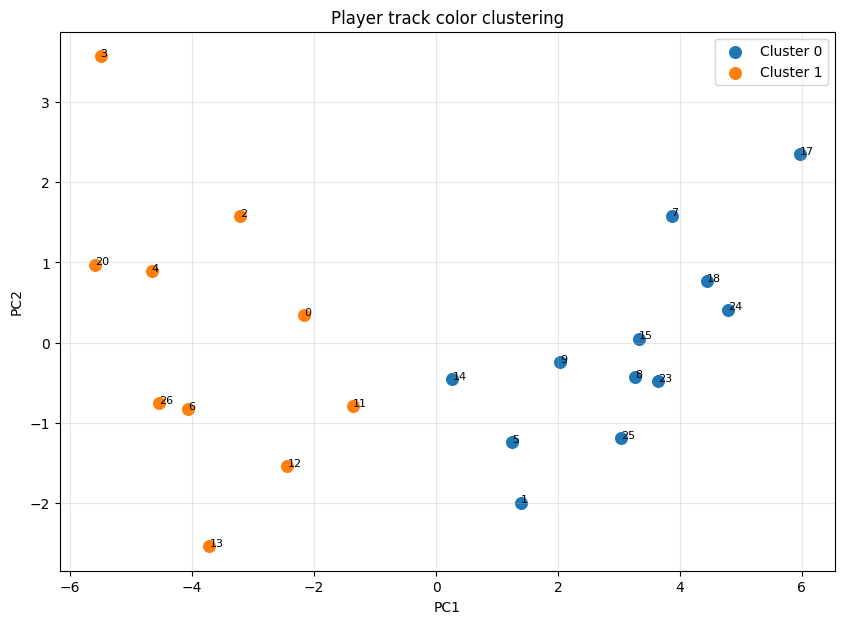

In [24]:
plt.figure(
    figsize=(10, 7)
)

for cluster_id in sorted(
    pca_df["cluster"].unique()
):

    subset = (
        pca_df[
            pca_df["cluster"]
            == cluster_id
        ]
    )

    plt.scatter(
        subset["pc1"],
        subset["pc2"],
        label=f"Cluster {cluster_id}",
        s=70,
    )

for _, row in pca_df.iterrows():

    plt.text(
        row["pc1"],
        row["pc2"],
        str(
            int(
                row["track_id"]
            )
        ),
        fontsize=8,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Player track color clustering"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

Funzione representative crop

In [25]:
def get_representative_crop(
    track_id
):

    rows = (
        tracks_df[
            tracks_df["track_id"]
            == track_id
        ]
        .sort_values(
            "confidence",
            ascending=False
        )
    )

    for _, row in rows.iterrows():

        frame_number = int(
            row["frame"]
        )

        frame_path = (
            FRAMES_DIR
            / f"{frame_number:06d}.jpg"
        )

        frame = cv2.imread(
            str(frame_path)
        )

        if frame is None:
            continue

        crop = extract_player_crop(
            frame,
            row["x1"],
            row["y1"],
            row["x2"],
            row["y2"],
        )

        if crop is not None:
            return crop

    return None

Galleria di tutti i Track

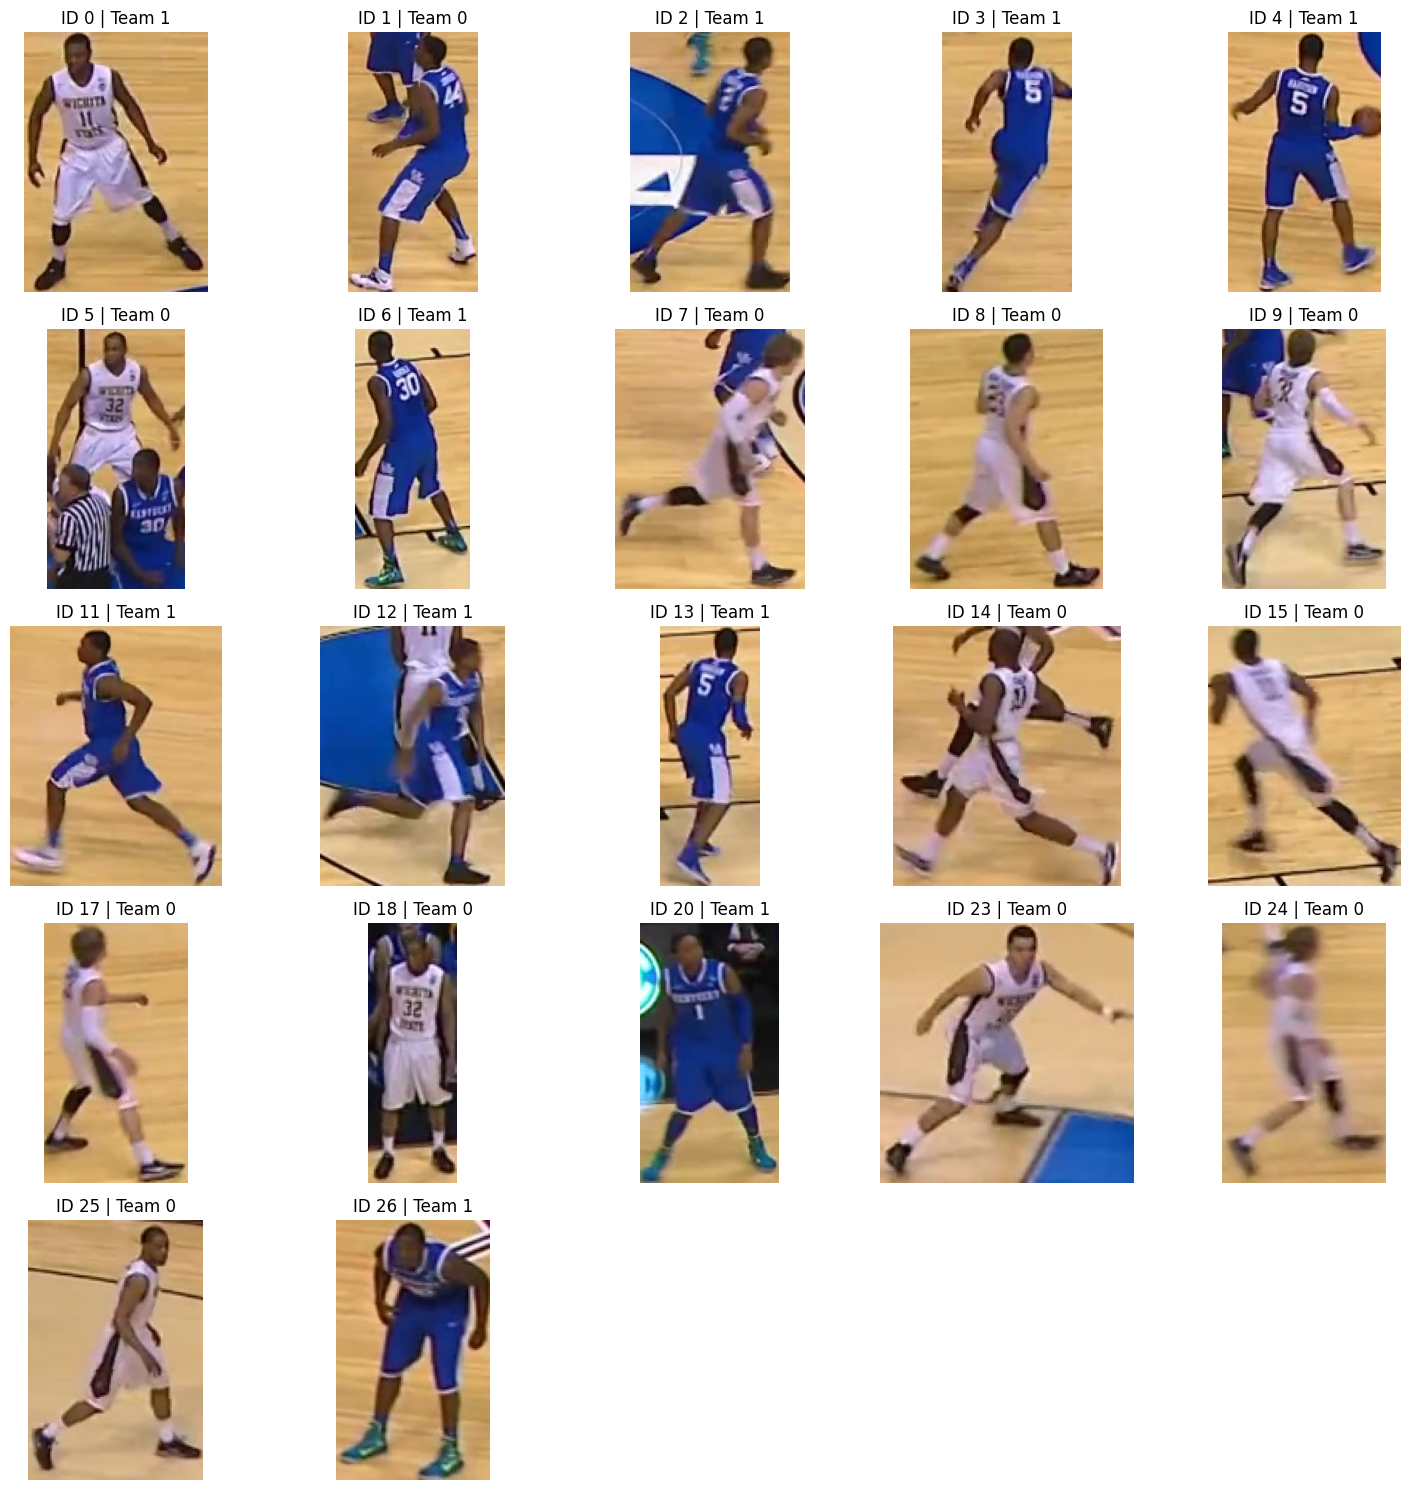

In [26]:
cluster_table = (
    player_track_features[
        ["cluster"]
    ]
    .reset_index()
)

n_tracks = len(
    cluster_table
)

cols = 5

rows = int(
    np.ceil(
        n_tracks / cols
    )
)

plt.figure(
    figsize=(
        15,
        rows * 3
    )
)

for i, row in cluster_table.iterrows():

    track_id = int(
        row["track_id"]
    )

    cluster_id = int(
        row["cluster"]
    )

    crop = get_representative_crop(
        track_id
    )

    ax = plt.subplot(
        rows,
        cols,
        i + 1
    )

    if crop is not None:

        ax.imshow(
            cv2.cvtColor(
                crop,
                cv2.COLOR_BGR2RGB
            )
        )

    ax.set_title(
        f"ID {track_id} | Team {cluster_id}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
def show_track_samples(
    track_id,
    n_samples=12
):

    track_data = (
        tracks_df[
            tracks_df["track_id"] == track_id
        ]
        .sort_values("frame")
        .copy()
    )

    if len(track_data) == 0:
        print("Track non trovato:", track_id)
        return

    indices = np.linspace(
        0,
        len(track_data) - 1,
        min(n_samples, len(track_data))
    ).astype(int)

    samples = track_data.iloc[
        indices
    ]

    cols = 4
    rows = int(
        np.ceil(
            len(samples) / cols
        )
    )

    plt.figure(
        figsize=(
            12,
            rows * 4
        )
    )

    for i, (_, row) in enumerate(
        samples.iterrows()
    ):

        frame_number = int(
            row["frame"]
        )

        frame_path = (
            FRAMES_DIR
            / f"{frame_number:06d}.jpg"
        )

        frame = cv2.imread(
            str(frame_path)
        )

        if frame is None:
            continue

        crop = extract_player_crop(
            frame,
            row["x1"],
            row["y1"],
            row["x2"],
            row["y2"],
        )

        ax = plt.subplot(
            rows,
            cols,
            i + 1
        )

        if crop is not None:

            ax.imshow(
                cv2.cvtColor(
                    crop,
                    cv2.COLOR_BGR2RGB
                )
            )

        ax.set_title(
            f"ID {track_id}\nframe {frame_number}"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

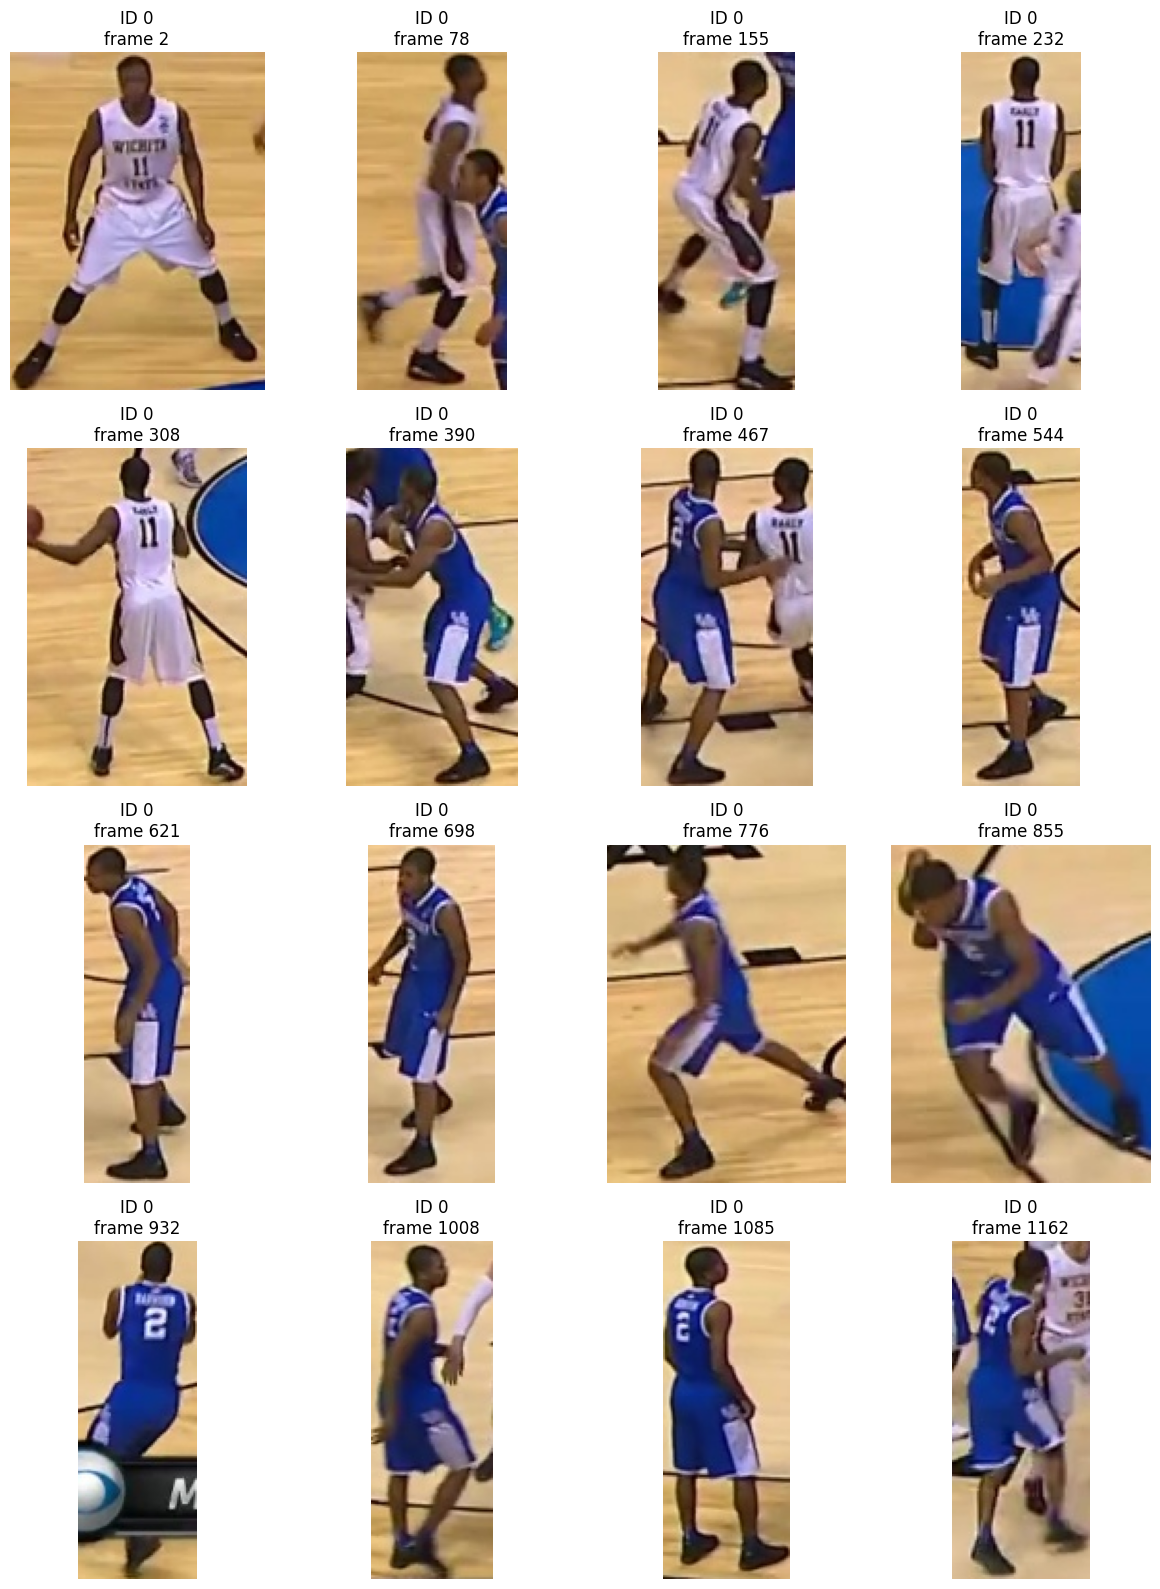

In [28]:
show_track_samples(
    0,
    n_samples=16
)

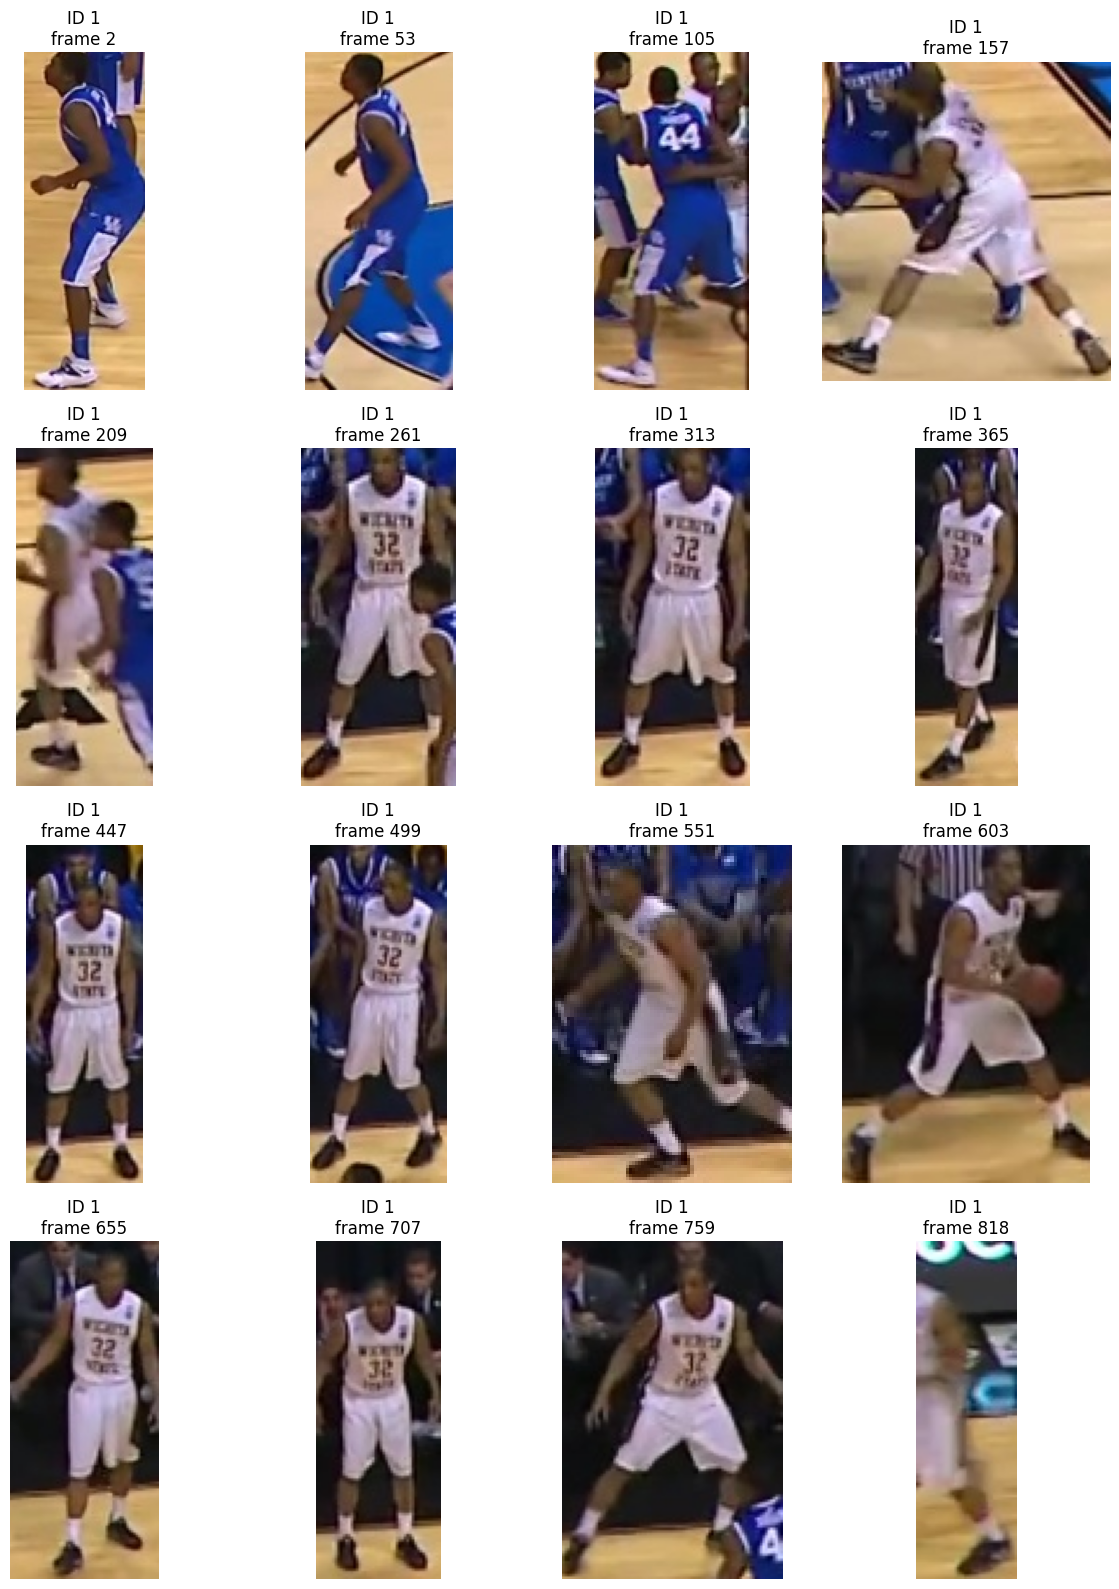

In [29]:
show_track_samples(
    1,
    n_samples=16
)

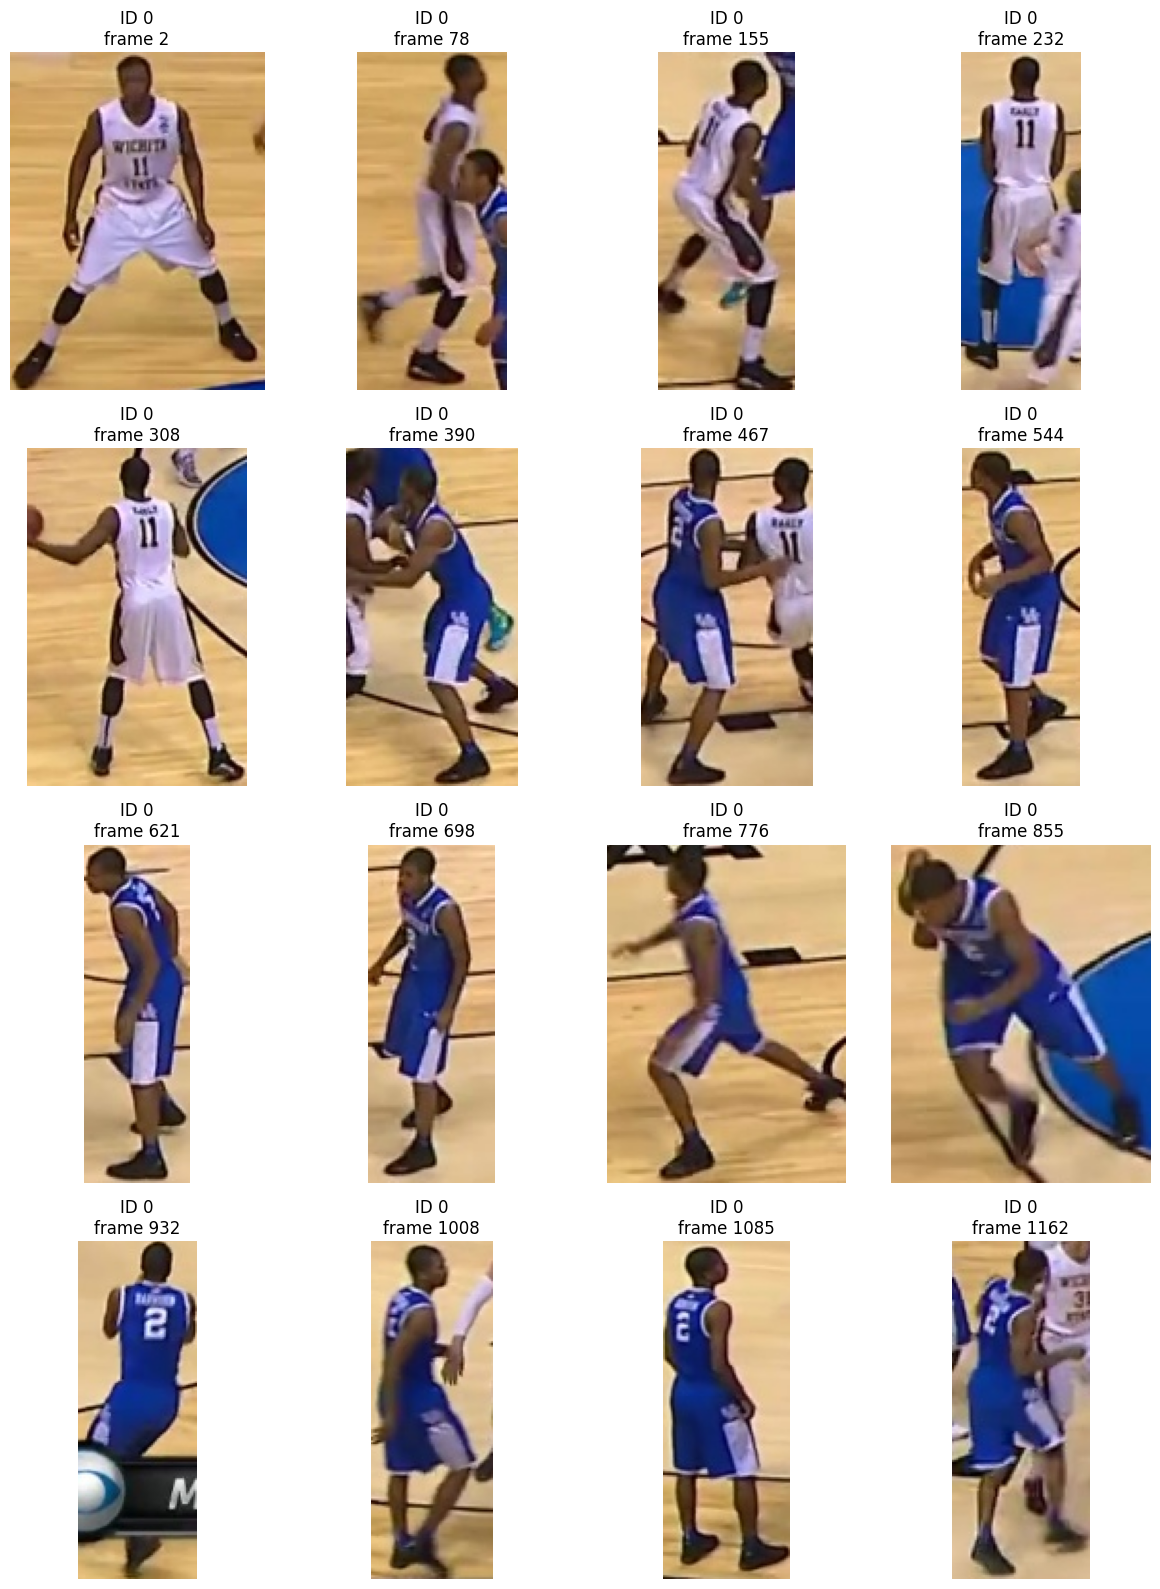

In [30]:
show_track_samples(
    0,
    n_samples=16
)

## Visualizzazione cluster separati
Una galleria per cluster


CLUSTER 0
Track IDs: [1, 5, 7, 8, 9, 14, 15, 17, 18, 23, 24, 25]


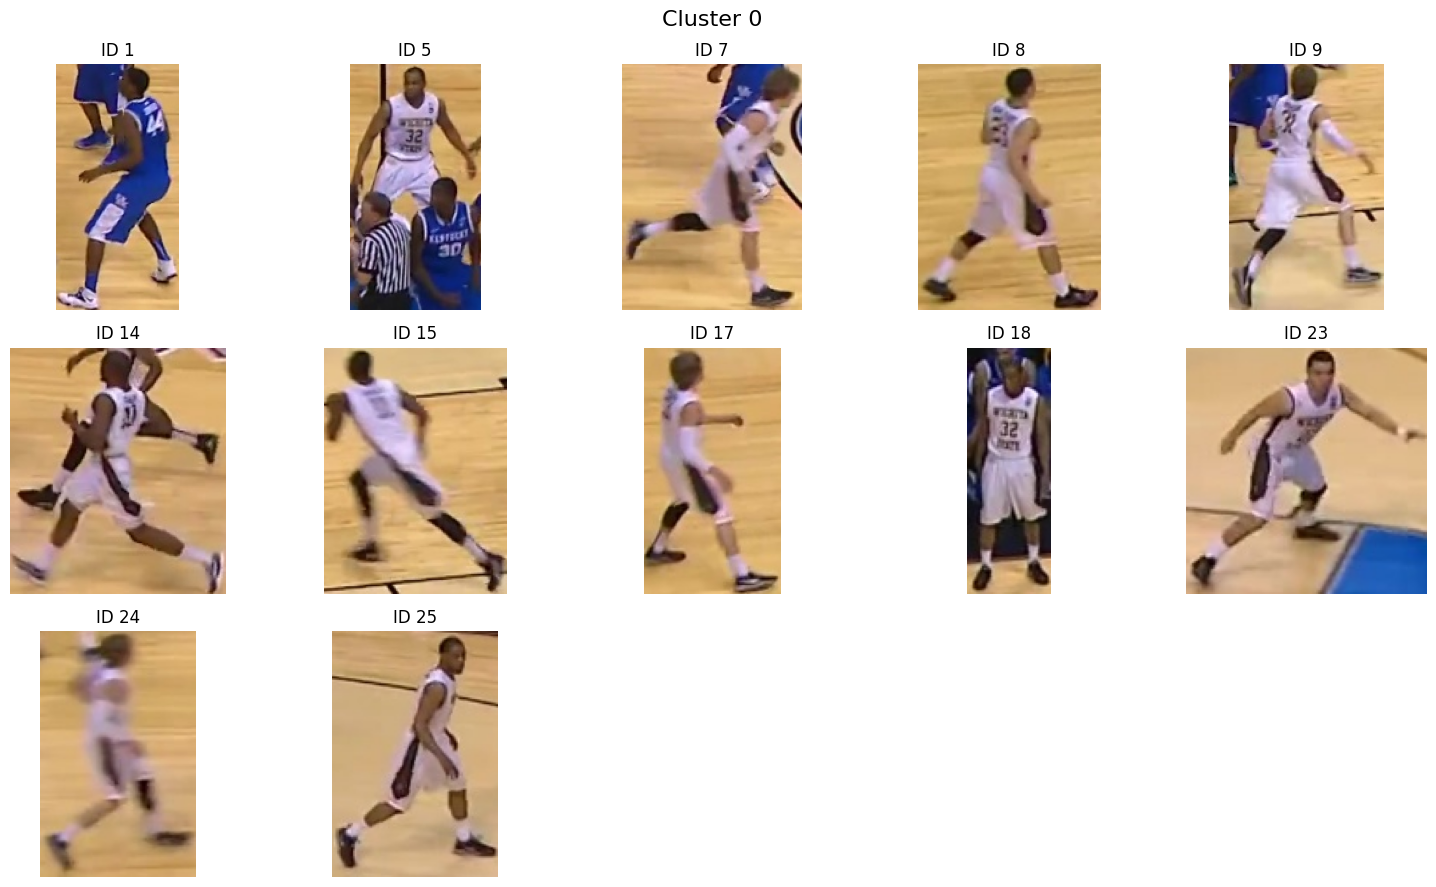


CLUSTER 1
Track IDs: [0, 2, 3, 4, 6, 11, 12, 13, 20, 26]


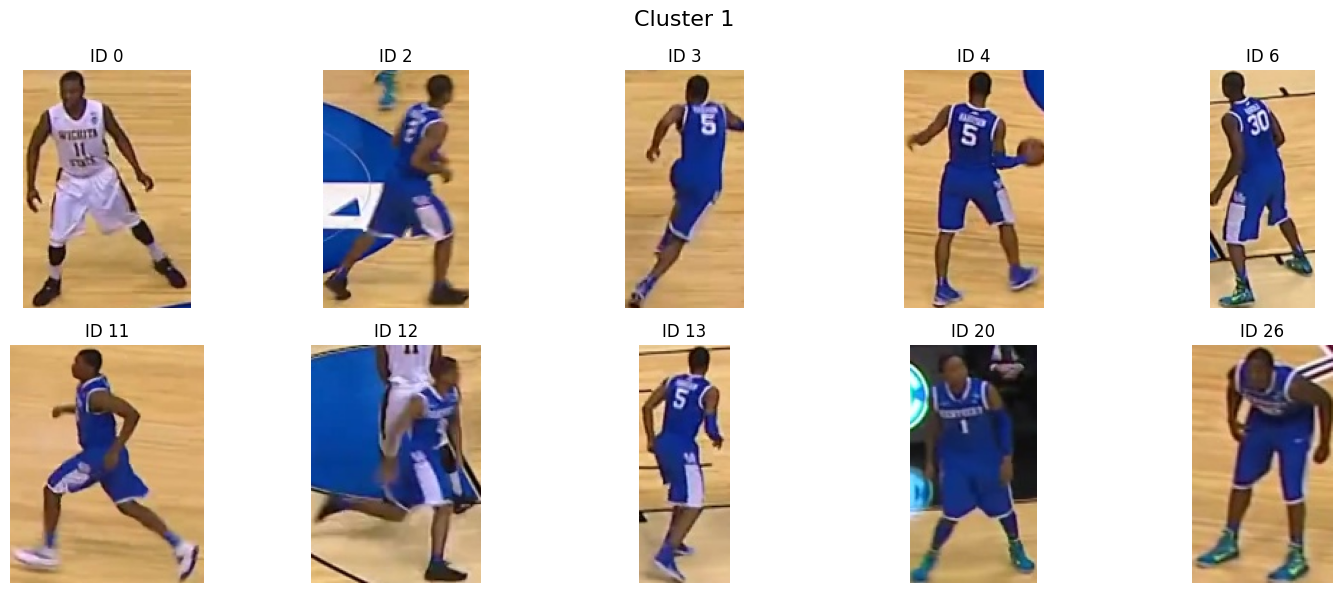

In [31]:
for cluster_id in sorted(
    cluster_table["cluster"].unique()
):

    track_ids = (
        cluster_table[
            cluster_table["cluster"]
            == cluster_id
        ]["track_id"]
        .tolist()
    )

    print(
        f"\nCLUSTER {cluster_id}"
    )

    print(
        "Track IDs:",
        track_ids
    )

    cols = 5

    rows = int(
        np.ceil(
            len(track_ids)
            / cols
        )
    )

    plt.figure(
        figsize=(
            15,
            max(
                3,
                rows * 3
            )
        )
    )

    for i, track_id in enumerate(
        track_ids
    ):

        crop = get_representative_crop(
            int(track_id)
        )

        ax = plt.subplot(
            rows,
            cols,
            i + 1
        )

        if crop is not None:

            ax.imshow(
                cv2.cvtColor(
                    crop,
                    cv2.COLOR_BGR2RGB
                )
            )

        ax.set_title(
            f"ID {int(track_id)}"
        )

        ax.axis("off")

    plt.suptitle(
        f"Cluster {cluster_id}",
        fontsize=16
    )

    plt.tight_layout()

    plt.show()

Tabella track → cluster

In [32]:
team_baseline_df = (
    player_track_features[
        ["cluster", "num_samples"]
    ]
    .reset_index()
)

team_baseline_df[
    "visual_class"
] = (
    "team_"
    + team_baseline_df[
        "cluster"
    ].astype(str)
)

display(
    team_baseline_df.sort_values(
        [
            "cluster",
            "track_id"
        ]
    )
)

,track_id,cluster,num_samples,visual_class
1,1,0,25,team_0
5,5,0,25,team_0
7,7,0,25,team_0
8,8,0,25,team_0
9,9,0,25,team_0
13,14,0,25,team_0
14,15,0,25,team_0
15,17,0,25,team_0
16,18,0,25,team_0
18,23,0,25,team_0


Aggiungo Arbitri

In [33]:
referee_df = pd.DataFrame({
    "track_id": REFEREE_TRACK_IDS,
    "cluster": -1,
    "num_samples": [
        track_features.loc[
            track_id,
            "num_samples"
        ]
        if track_id in track_features.index
        else 0
        for track_id in REFEREE_TRACK_IDS
    ],
    "visual_class": "referee",
})

team_baseline_df = pd.concat(
    [
        team_baseline_df,
        referee_df,
    ],
    ignore_index=True,
)

display(
    team_baseline_df.sort_values(
        "track_id"
    )
)

,track_id,cluster,num_samples,visual_class
0,0,1,25,team_1
1,1,0,25,team_0
2,2,1,25,team_1
3,3,1,25,team_1
4,4,1,25,team_1
5,5,0,25,team_0
6,6,1,25,team_1
7,7,0,25,team_0
8,8,0,25,team_0
9,9,0,25,team_0


Salva CSV

In [34]:
TEAM_CSV = (
    OUTPUT_DIR
    / "track_visual_clusters.csv"
)

team_baseline_df.to_csv(
    TEAM_CSV,
    index=False
)

print(
    "Saved:",
    TEAM_CSV
)

print(
    "Exists:",
    TEAM_CSV.exists()
)

Saved: /content/drive/MyDrive/basketball-thesis/experiments/team_classification/v_00HRwkvvjtQ_c001/track_visual_clusters.csv
Exists: True


Integrare il cluster nel tracking originale

In [35]:
tracks_with_cluster_df = (
    tracks_df
    .merge(
        team_baseline_df[
            [
                "track_id",
                "cluster",
                "visual_class"
            ]
        ],
        on="track_id",
        how="left",
    )
)

display(
    tracks_with_cluster_df.head()
)

,frame,time,track_id,confidence,x1,y1,x2,y2,cluster,visual_class
0,2,0.04,0,0.946324,434.150208,268.251038,560.730225,436.969086,1.0,team_1
1,2,0.04,1,0.918907,973.851013,390.865112,1050.417969,604.696655,0.0,team_0
2,2,0.04,2,0.847887,636.885437,416.111542,768.735291,625.620422,1.0,team_1
3,2,0.04,3,0.852696,990.499023,290.476715,1053.694336,497.539978,1.0,team_1
4,2,0.04,4,0.760175,652.945068,272.642029,758.719971,433.214264,1.0,team_1


Controllo

In [36]:
 print(
    tracks_with_cluster_df[
        "visual_class"
    ]
    .value_counts(
        dropna=False
    )
)

visual_class
team_1     5714
team_0     5156
referee      39
NaN           2
Name: count, dtype: int64


Salva tracking arricchito

In [37]:
ENRICHED_TRACKS_CSV = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_tracks_with_visual_cluster.csv"
)

tracks_with_cluster_df.to_csv(
    ENRICHED_TRACKS_CSV,
    index=False
)

print(
    "Saved:",
    ENRICHED_TRACKS_CSV
)

print(
    "Exists:",
    ENRICHED_TRACKS_CSV.exists()
)

Saved: /content/drive/MyDrive/basketball-thesis/experiments/team_classification/v_00HRwkvvjtQ_c001/v_00HRwkvvjtQ_c001_tracks_with_visual_cluster.csv
Exists: True


## Risultato baseline

È stata costruita una prima pipeline di classificazione visiva dei track:

1. estrazione delle bounding box dei giocatori;
2. selezione della regione della maglia;
3. estrazione di feature colore HSV/LAB;
4. aggregazione temporale delle feature per track;
5. clustering unsupervised dei track;
6. visualizzazione dei cluster;
7. salvataggio della classe visiva nel tracking.

### Limiti attuali

Il clustering non assegna ancora automaticamente un significato semantico
ai gruppi.

I cluster devono essere verificati per determinare se corrispondono a:

- Team A;
- Team B;
- arbitri / false positive.

Inoltre eventuali ID switch del tracker possono propagarsi alla
classificazione della squadra.

Questa baseline verrà successivamente raffinata utilizzando informazioni
temporali e, se necessario, feature visive più robuste.